# Fake News Detection Using NLP and Machine Learning

- **Student_1:** Gahramanova Laman
- **Student_1_ID:** 5115406
- **Student_2:** Novruzov Bakhtiyar
- **Student_2_ID:** ...

## Assignment Registration in the assignment table (link in the Moodle webpage)

- **Assignment Type:** Text Analysis
- **Learning Type:** Classification
- **Implemented Learning Algorithms:** TF-IDF + Multinomial Naive Bayes
- **Presentation Date:** 
- **Dataset Name:** Fake and Real News Dataset
- **Dataset URL:** https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
- **Repository URL:** https://github.com/Gahramanoval301/Machine-Learning-Assignment
- **Student Names:** Laman, Bakhtiyar

## AI Assistance

Used ChatGPT for:
- GridSearchCV syntax
- notebook organization
- understanding the assignment structure
- selecting an appropriate NLP dataset
- planning the project workflow and implementation steps


## Dataset Explanation

This dataset contains fake and real news articles.
The goal is binary text classification.

## Problem Summary

This project addresses the task of fake news detection using natural language processing techniques. Given a news article, the objective is to classify it into one of two categories: fake or real. 

The solution involves preprocessing text data, extracting features using TF-IDF, and training a Multinomial Naive Bayes classifier for binary classification.

### Import Libraries and Dataset

In [101]:

import pandas as pd
import numpy as np
import os
import re
import kagglehub



## Part 1 - Loading the dataset

In [102]:
# Download latest version
path = kagglehub.dataset_download(
    "clmentbisaillon/fake-and-real-news-dataset"
)

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\clmentbisaillon\fake-and-real-news-dataset\versions\1


### Check Files

In [103]:
print("Files in dataset folder:")
print(os.listdir(path))

Files in dataset folder:
['Fake.csv', 'True.csv']


### Load datasets

In [104]:
fake_df = pd.read_csv(path + "/Fake.csv")
true_df = pd.read_csv(path + "/True.csv")

### Review Fake News

In [105]:
print("Fake News Sample:")
fake_df.head()

Fake News Sample:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


### Preview Real News

In [106]:
print("Real News Sample:")
true_df.head()

Real News Sample:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


#### We can also combine the datasets

In [107]:
fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)

## Part 2 – Feature engineering

Machine learning models cannot understand text → we convert text into numerical vectors.

Machine learning models cannot directly understand raw text.

Because of this, we must preprocess the text and convert it into numerical features.

In this section, we:
1. Clean the text
2. Split the dataset into training and testing sets
3. Convert text into numerical vectors using TF-IDF
4. Show examples before and after preprocessing


### Text Preprocessing (Cleaning)

Real-world text contains:
- uppercase and lowercase letters
- punctuation
- symbols
- unnecessary spaces

Cleaning the text helps the model focus on meaningful words.

The preprocessing steps are:
- convert text to lowercase
- remove special characters and numbers
- remove extra spaces

In [108]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


In [109]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head(3)

,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump just couldn t wish all americans ...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",on friday it was revealed that former milwauke...


### Train-Test split

The dataset is divided into:
- Training set (80%) → used to train the model
- Test set (20%) → used to evaluate the model

We use `random_state=42` to ensure reproducible results.

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## TF-IDF Vectorization

Machine learning algorithms work with numbers, not raw text.

TF-IDF (Term Frequency - Inverse Document Frequency) converts text into numerical vectors.

TF-IDF gives:
- higher importance to meaningful words
- lower importance to very common words

For example:
- words like "government" or "breaking" may help classify fake news
- common words like "the" or "is" are less useful

We also remove English stopwords to reduce noise.

In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

### Why do we fit only on training data?

The vectorizer is fitted only on the training set to prevent data leakage.

The test set must remain completely unseen during training.

### Examples

In [112]:
for i in range(2):
    print(f"TRAIN Example {i+1}")

    print("\nCleaned Text:")
    print(X_train.iloc[i][:300])

    print("\n" + "="*80 + "\n")

for i in range(2):
    print(f"TEST Example {i+1}")

    print("\nCleaned Text:")
    print(X_test.iloc[i][:300])

    print("\n" + "="*80 + "\n")

TRAIN Example 1

Cleaned Text:
athens reuters turkish president tayyip erdogan said on thursday that u s president donald trump s unfortunate decision to recognize jerusalem as the capital of israel was trampling on international laws erdogan speaking in athens after talks with prime minister alexis tsipras also said turkey wante


TRAIN Example 2

Cleaned Text:
ted cruz would be fair honest and most of all he would follow the law he would hands down be one of the best choices for this position president elect donald trump is considering nominating texas senator ted cruz to serve as u s attorney general according to a person familiar with the matter cruz wa


TEST Example 1

Cleaned Text:
 st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge jeanine pirro s show recently while discussing the halt that was imposed on president 



### TF-IDF Feature Representation

After preprocessing, the text is transformed into numerical vectors.

Each column represents a word feature, and each value represents the importance of that word in the document.

In [113]:
print("TF-IDF matrix shape:", X_train_tfidf.shape)

print("\nFirst 20 features in the vocabulary:")
print(vectorizer.get_feature_names_out()[:20])

print("\nFirst training example vector values:")
print(X_train_tfidf.toarray()[0][:20])

print("\nNumber of non-zero TF-IDF values in first document:")
print(X_train_tfidf[0].nnz)

# Show words that actually appear in the first document
idxs = X_train_tfidf[0].nonzero()[1]

print("\nImportant words detected in first document:")
print(vectorizer.get_feature_names_out()[idxs])

TF-IDF matrix shape: (35918, 5000)

First 20 features in the vocabulary:
['abadi' 'abandon' 'abandoned' 'abbas' 'abc' 'abdullah' 'abe' 'abedin'
 'ability' 'able' 'abortion' 'abortions' 'abroad' 'absence' 'absolute'
 'absolutely' 'absurd' 'abu' 'abuse' 'abuses']

First training example vector values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Number of non-zero TF-IDF values in first document:
24

Important words detected in first document:
['reuters' 'turkish' 'president' 'tayyip' 'erdogan' 'said' 'thursday'
 'donald' 'trump' 'decision' 'recognize' 'jerusalem' 'capital' 'israel'
 'international' 'laws' 'speaking' 'talks' 'prime' 'minister' 'turkey'
 'wanted' 'solution' 'island']


The output above shows the numerical TF-IDF representation of the first training example.

Each number represents the importance of a specific word feature in the article.

Higher values indicate more important words for that document.

## Part 3

## Part 3 – Implementing a Learning Algorithm

In this section, we implement the Multinomial Naive Bayes algorithm for fake news classification.

Naive Bayes is a probabilistic machine learning algorithm commonly used for text classification problems such as:
- spam detection
- sentiment analysis
- fake news detection

The algorithm works especially well with TF-IDF features because it learns word occurrence patterns in documents.

Multinomial Naive Bayes was chosen because:
- it performs efficiently on text data
- it works well with high-dimensional sparse matrices like TF-IDF
- it is fast to train
- it is commonly used in NLP classification tasks

The algorithm predicts whether a news article is fake or real based on probability calculations.

It assumes that words contribute independently to the prediction.

For example:
- words such as "breaking", "shocking", or "exclusive" may appear more frequently in fake news
- words such as "official", "report", or "government" may appear more frequently in real news

The model calculates probabilities for each class and selects the class with the highest probability.

$$
P(C \mid X) = \frac{P(X \mid C) \cdot P(C)}{P(X)}
$$

Where:
- C represents the class (fake or real)
- X represents the document features
- The algorithm chooses the class with the highest posterior probability

### Hyperparameters

The main hyperparameter used in Multinomial Naive Bayes is:

- `alpha` → smoothing parameter

Smoothing helps prevent zero probabilities for unseen words.

Different alpha values may affect model performance.

### Training and Prediction Functions

To organize the implementation clearly, separate functions were created for:
- training the model
- generating predictions

This improves code readability and allows easy experimentation with different hyperparameter values.

In [114]:
from sklearn.naive_bayes import MultinomialNB

def train_model(X_train, y_train, alpha=1.0):
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train, y_train)
    return model

In [115]:
def predict_model(model, X_test):
    predictions = model.predict(X_test)
    return predictions

The model was trained using the TF-IDF feature vectors from the training dataset and then used to generate predictions for the test dataset.

In [116]:
model = train_model(X_train_tfidf, y_train, alpha=1.0)

In [117]:
y_pred = predict_model(model, X_test_tfidf)

### Hyperparameter Experiments (Alpha Tuning)

Different values of the `alpha` hyperparameter were tested to evaluate how smoothing affects the performance of the Multinomial Naive Bayes model.

The experiments were evaluated using:
- Accuracy
- F1-score

Accuracy measures the overall percentage of correct predictions.

F1-score is especially important for classification problems because it balances:
- precision
- recall

Different alpha values may improve or reduce the model performance depending on the dataset.

- Smaller alpha values:
  - apply less smoothing
  - make the model rely more strongly on the training data
  - may lead to overfitting

- Larger alpha values:
  - apply stronger smoothing
  - make the model more generalized
  - may reduce overfitting but can also reduce accuracy

In [118]:
from sklearn.metrics import f1_score, confusion_matrix

alphas = [0.1, 0.5, 1.0, 2.0]

f1_scores = []
best_alpha = None
best_f1 = 0

for alpha in alphas:
    model = train_model(X_train_tfidf, y_train, alpha=alpha)
    y_pred = predict_model(model, X_test_tfidf)

    f1 = f1_score(y_test, y_pred, average="macro")

    f1_scores.append(f1)

    print(f"Alpha: {alpha} -> F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

Alpha: 0.1 -> F1: 0.9284
Alpha: 0.5 -> F1: 0.9282
Alpha: 1.0 -> F1: 0.9276
Alpha: 2.0 -> F1: 0.9266


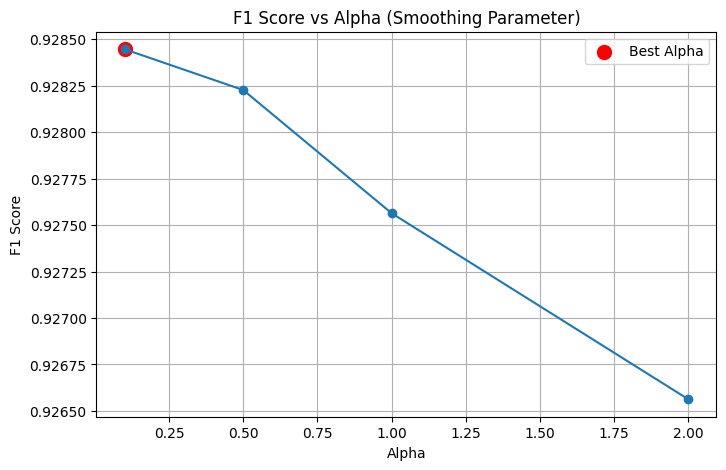

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(alphas, f1_scores, marker='o')

plt.title("F1 Score vs Alpha (Smoothing Parameter)")
plt.xlabel("Alpha")
plt.ylabel("F1 Score")

# highlight best point
plt.scatter(best_alpha, best_f1, color='red', s=100, label='Best Alpha')

plt.legend()
plt.grid(True)

plt.show()

In [120]:
baseline_model = train_model(X_train_tfidf, y_train, alpha=1.0)
y_pred_base = predict_model(baseline_model, X_test_tfidf)

base_f1 = f1_score(y_test, y_pred_base)

print("\n=== BASELINE MODEL (alpha = 1.0) ===")
print("F1 Score:", round(base_f1, 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))


=== BASELINE MODEL (alpha = 1.0) ===
F1 Score: 0.9231
Confusion Matrix:
[[4443  290]
 [ 358 3889]]


In [121]:
best_model = train_model(X_train_tfidf, y_train, alpha=best_alpha)
y_pred_best = predict_model(best_model, X_test_tfidf)

best_f1 = f1_score(y_test, y_pred_best)

print("\n=== BEST MODEL ===")
print("Best Alpha:", best_alpha)
print("Best F1 Score:", round(best_f1, 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


=== BEST MODEL ===
Best Alpha: 0.1
Best F1 Score: 0.9239
Confusion Matrix:
[[4453  280]
 [ 360 3887]]


In [122]:
print("\n=== FINAL COMPARISON ===")
print(f"Baseline (alpha=1.0): F1 = {base_f1:.4f}")
print(f"Best model (alpha={best_alpha}): F1 = {best_f1:.4f}")


=== FINAL COMPARISON ===
Baseline (alpha=1.0): F1 = 0.9231
Best model (alpha=0.1): F1 = 0.9239


The experiments show how different smoothing values affect classification performance.

The best-performing alpha value can be selected for the final model training and evaluation.